In [1]:
!wget -q http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip glove.6B.100d.txt
!ls

glove.6B.100d.txt  glove.6B.zip  sample_data


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import time
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt


torch.manual_seed(42)
np.random_seed = 42

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
class EmotionDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=50):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        tokens = text.lower().split()
        indices = [self.vocab.get(token, self.vocab['<UNK>']) for token in tokens]

        if len(indices) < self.max_len:
            indices += [self.vocab['<PAD>']] * (self.max_len - len(indices))
        else:
            indices = indices[:self.max_len]

        return torch.tensor(indices, dtype=torch.long), torch.tensor(label, dtype=torch.long)

In [4]:
def load_glove_embeddings(glove_path, embedding_dim=100):
    print(f"Loading GloVe embeddings from {glove_path}...")
    embeddings_index = {}
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    print(f"Loaded {len(embeddings_index)} word vectors")
    return embeddings_index

In [5]:
def build_vocab_and_embeddings(texts, glove_embeddings, embedding_dim=100):
    print("Building vocabulary...")
    word_freq = Counter()
    for text in texts:
        tokens = text.lower().split()
        word_freq.update(tokens)

    vocab = {'<PAD>': 0, '<UNK>': 1}
    idx = 2
    for word in word_freq:
        vocab[word] = idx
        idx += 1

    vocab_size = len(vocab)
    embedding_matrix = np.random.randn(vocab_size, embedding_dim).astype(np.float32) * 0.01
    embedding_matrix[0] = np.zeros(embedding_dim)

    found = 0
    for word, idx in vocab.items():
        if word in glove_embeddings:
            embedding_matrix[idx] = glove_embeddings[word]
            found += 1

    print(f"Vocabulary size: {vocab_size}")
    print(f"Found {found}/{vocab_size} words in GloVe")

    return vocab, embedding_matrix

In [6]:
def compute_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None, zero_division=0)
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred)

    return {
        'accuracy': accuracy,
        'per_class_precision': precision,
        'per_class_recall': recall,
        'per_class_f1': f1,
        'macro_precision': macro_precision,
        'macro_recall': macro_recall,
        'macro_f1': macro_f1,
        'confusion_matrix': cm
    }

def print_metrics(metrics, dataset_name):
    print(f"\n{dataset_name} Results:")
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Macro Precision: {metrics['macro_precision']:.4f}")
    print(f"Macro Recall: {metrics['macro_recall']:.4f}")
    print(f"Macro F1: {metrics['macro_f1']:.4f}")

    print("\nPer-class metrics:")
    emotion_names = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
    for i, emotion in enumerate(emotion_names):
        print(f"  {emotion:10s}: P={metrics['per_class_precision'][i]:.4f}, "
              f"R={metrics['per_class_recall'][i]:.4f}, F1={metrics['per_class_f1'][i]:.4f}")

    print(f"\nConfusion Matrix:")
    print(metrics['confusion_matrix'])

In [7]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, embedding_matrix, dropout=0.5):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))

        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        last_hidden = hidden[-1]
        dropped = self.dropout(last_hidden)
        return self.fc(dropped)

In [8]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, embedding_matrix, dropout=0.5):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))

        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]
        concat = torch.cat([forward_hidden, backward_hidden], dim=1)
        return self.fc(self.dropout(concat))


class BiRNNClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, embedding_matrix, dropout=0.5):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))

        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        rnn_out, hidden = self.rnn(embedded)
        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]
        concat = torch.cat([forward_hidden, backward_hidden], dim=1)
        return self.fc(self.dropout(concat))

In [9]:
class BiLSTMWithAttention(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, embedding_matrix,
                 dropout=0.5, attention_dim=128):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))

        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.attention_W = nn.Linear(hidden_dim * 2, attention_dim)
        self.attention_v = nn.Linear(attention_dim, 1, bias=False)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x, return_attention=False):
        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)
        e_t = self.attention_v(torch.tanh(self.attention_W(lstm_out)))
        attention_weights = torch.softmax(e_t, dim=1)
        context = torch.sum(attention_weights * lstm_out, dim=1)
        out = self.fc(self.dropout(context))

        if return_attention:
            return out, attention_weights.squeeze(-1)
        return out

In [41]:
class TransformerEncoderClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_heads, num_layers, hidden_dim,
                 num_classes, max_len, dropout=0.1):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.pos_embedding = nn.Parameter(torch.randn(max_len, embedding_dim))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim, nhead=num_heads,
            dim_feedforward=hidden_dim, dropout=dropout, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(embedding_dim, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        seq_len = x.size(1)
        embedded += self.pos_embedding[:seq_len, :].unsqueeze(0)
        mask = (x == 0)
        out = self.transformer_encoder(embedded, src_key_padding_mask=mask)
        pooled = out.mean(dim=1)
        return self.fc(self.dropout(pooled))

In [11]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)


def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    metrics = compute_metrics(all_labels, all_preds)
    metrics['loss'] = total_loss / len(dataloader)
    return metrics

In [12]:
def train_model(model, train_loader, dev_loader, criterion, optimizer, num_epochs, model_name):
    print(f"\nTraining {model_name}...")
    print("=" * 60)

    best_dev_f1 = 0

    for epoch in range(num_epochs):
        start_time = time.time()

        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)

        train_metrics = evaluate(model, train_loader, criterion, device)
        dev_metrics = evaluate(model, dev_loader, criterion, device)

        epoch_time = time.time() - start_time

        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | "
              f"Train Acc: {train_metrics['accuracy']:.4f} | Train F1: {train_metrics['macro_f1']:.4f} | "
              f"Dev Acc: {dev_metrics['accuracy']:.4f} | Dev F1: {dev_metrics['macro_f1']:.4f} | "
              f"Time: {epoch_time:.2f}s")

        if dev_metrics['macro_f1'] > best_dev_f1:
            best_dev_f1 = dev_metrics['macro_f1']
            torch.save(model.state_dict(), f'{model_name.lower().replace(" ", "_")}_best.pt')

    model.load_state_dict(torch.load(f'{model_name.lower().replace(" ", "_")}_best.pt'))
    print(f"\nBest Dev F1: {best_dev_f1:.4f}")
    return model

In [13]:
def plot_attention_heatmap(words, attn, title="Attention Heatmap"):
    attn = np.array(attn)[None, :]  # (1, seq_len)

    plt.figure(figsize=(min(14, len(words)), 2.5))
    plt.imshow(attn, aspect="auto", cmap='hot')
    plt.xticks(range(len(words)), words, rotation=45, ha='right')
    plt.yticks([])
    plt.title(title)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

In [14]:
def get_example_from_loader(model, data_loader, device, idx2word,
                            want_correct=True, max_batches=50):
    model.eval()
    with torch.no_grad():
        for b_i, batch in enumerate(data_loader):
            if b_i >= max_batches:
                break

            inputs, labels = batch
            inputs = inputs.to(device)
            labels = labels.to(device)

            logits, attn = model(inputs, return_attention=True)
            preds = logits.argmax(dim=1)

            mask = (preds == labels) if want_correct else (preds != labels)

            if mask.any():
                idx = mask.nonzero(as_tuple=True)[0][0].item()

                sent_ids = inputs[idx].cpu().tolist()
                attn_weights = attn[idx].cpu().tolist()

                true_label = labels[idx].item()
                pred_label = preds[idx].item()

                words, weights = [], []
                for tid, w in zip(sent_ids, attn_weights):
                    if tid == PAD_IDX:
                        continue
                    words.append(idx2word.get(tid, "<UNK>"))
                    weights.append(w)

                return {
                    "words": words,
                    "attn": weights,
                    "true_label": true_label,
                    "pred_label": pred_label,
                }

    return None

In [17]:
train_df = pd.read_csv('training.csv')
dev_df = pd.read_csv('validation.csv')
test_df = pd.read_csv('test.csv')

print(f"Train size: {len(train_df)}")
print(f"Dev size: {len(dev_df)}")
print(f"Test size: {len(test_df)}")


Train size: 16000
Dev size: 2000
Test size: 2000


In [18]:
glove_embeddings = load_glove_embeddings('glove.6B.100d.txt', embedding_dim=100)

vocab, embedding_matrix = build_vocab_and_embeddings(
    train_df['text'].tolist(), glove_embeddings, embedding_dim=100
)

max_len = 50
batch_size = 32

train_dataset = EmotionDataset(train_df['text'].tolist(), train_df['label'].tolist(), vocab, max_len)
dev_dataset = EmotionDataset(dev_df['text'].tolist(), dev_df['label'].tolist(), vocab, max_len)
test_dataset = EmotionDataset(test_df['text'].tolist(), test_df['label'].tolist(), vocab, max_len)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

criterion = nn.CrossEntropyLoss()

Loading GloVe embeddings from glove.6B.100d.txt...
Loaded 400000 word vectors
Building vocabulary...
Vocabulary size: 15214
Found 14212/15214 words in GloVe


In [19]:
print("\n--- LSTM ---")
lstm_model = LSTMClassifier(
    vocab_size=len(vocab),
    embedding_dim=100,
    hidden_dim=256,
    num_classes=6,
    embedding_matrix=embedding_matrix,
    dropout=0.3
).to(device)

#optimizer = optim.Adam(lstm_model.parameters(), lr=1e-4)
optimizer = optim.SGD(lstm_model.parameters(),lr=1e-2,momentum=0.9)
lstm_model = train_model(
    lstm_model, train_loader, dev_loader, criterion, optimizer,
    num_epochs=25, model_name="LSTM"
)


--- LSTM ---

Training LSTM...
Epoch 1/25 | Train Loss: 1.5886 | Train Acc: 0.3352 | Train F1: 0.0838 | Dev Acc: 0.3520 | Dev F1: 0.0868 | Time: 4.71s
Epoch 2/25 | Train Loss: 1.5763 | Train Acc: 0.3351 | Train F1: 0.0837 | Dev Acc: 0.3520 | Dev F1: 0.0868 | Time: 3.22s
Epoch 3/25 | Train Loss: 1.5764 | Train Acc: 0.3351 | Train F1: 0.0837 | Dev Acc: 0.3520 | Dev F1: 0.0868 | Time: 3.27s
Epoch 4/25 | Train Loss: 1.5760 | Train Acc: 0.3351 | Train F1: 0.0837 | Dev Acc: 0.3520 | Dev F1: 0.0868 | Time: 3.53s
Epoch 5/25 | Train Loss: 1.5760 | Train Acc: 0.3352 | Train F1: 0.0838 | Dev Acc: 0.3520 | Dev F1: 0.0868 | Time: 3.64s
Epoch 6/25 | Train Loss: 1.5762 | Train Acc: 0.3351 | Train F1: 0.0837 | Dev Acc: 0.3520 | Dev F1: 0.0868 | Time: 3.27s
Epoch 7/25 | Train Loss: 1.5762 | Train Acc: 0.3353 | Train F1: 0.0840 | Dev Acc: 0.3520 | Dev F1: 0.0868 | Time: 3.23s
Epoch 8/25 | Train Loss: 1.5759 | Train Acc: 0.3353 | Train F1: 0.0839 | Dev Acc: 0.3520 | Dev F1: 0.0868 | Time: 3.91s
Epoch 9/

In [20]:
print("\nLSTM - Development Set:")
lstm_dev_metrics = evaluate(lstm_model, dev_loader, criterion, device)
print_metrics(lstm_dev_metrics, "LSTM Dev")


LSTM - Development Set:

LSTM Dev Results:
Accuracy: 0.3510
Macro Precision: 0.0972
Macro Recall: 0.1666
Macro F1: 0.0901

Per-class metrics:
  sadness   : P=0.2308, R=0.0109, F1=0.0208
  joy       : P=0.3526, R=0.9886, F1=0.5198
  love      : P=0.0000, R=0.0000, F1=0.0000
  anger     : P=0.0000, R=0.0000, F1=0.0000
  fear      : P=0.0000, R=0.0000, F1=0.0000
  surprise  : P=0.0000, R=0.0000, F1=0.0000

Confusion Matrix:
[[  6 544   0   0   0   0]
 [  8 696   0   0   0   0]
 [  0 178   0   0   0   0]
 [  5 270   0   0   0   0]
 [  6 206   0   0   0   0]
 [  1  80   0   0   0   0]]


In [21]:
print("\nLSTM - Test Set:")
lstm_test_metrics = evaluate(lstm_model, test_loader, criterion, device)
print_metrics(lstm_test_metrics, "LSTM Test")


LSTM - Test Set:

LSTM Test Results:
Accuracy: 0.3475
Macro Precision: 0.1050
Macro Recall: 0.1671
Macro F1: 0.0908

Per-class metrics:
  sadness   : P=0.2812, R=0.0155, F1=0.0294
  joy       : P=0.3486, R=0.9871, F1=0.5152
  love      : P=0.0000, R=0.0000, F1=0.0000
  anger     : P=0.0000, R=0.0000, F1=0.0000
  fear      : P=0.0000, R=0.0000, F1=0.0000
  surprise  : P=0.0000, R=0.0000, F1=0.0000

Confusion Matrix:
[[  9 572   0   0   0   0]
 [  9 686   0   0   0   0]
 [  2 157   0   0   0   0]
 [  4 271   0   0   0   0]
 [  3 221   0   0   0   0]
 [  5  61   0   0   0   0]]


In [22]:
print("\n--- BiLSTM ---")
bilstm_model = BiLSTMClassifier(
    vocab_size=len(vocab),
    embedding_dim=100,
    hidden_dim=64,
    num_classes=6,
    embedding_matrix=embedding_matrix,
    dropout=0.2
).to(device)
optimizer = optim.Adam(bilstm_model.parameters(), lr=1e-3)
#optimizer = optim.SGD(bilstm_model.parameters(),lr=1e-2,momentum=0.9)
bilstm_model = train_model(
    bilstm_model, train_loader, dev_loader, criterion, optimizer,
    num_epochs=15, model_name="BiLSTM"
)


--- BiLSTM ---

Training BiLSTM...
Epoch 1/15 | Train Loss: 1.2436 | Train Acc: 0.7680 | Train F1: 0.5152 | Dev Acc: 0.7445 | Dev F1: 0.4988 | Time: 3.22s
Epoch 2/15 | Train Loss: 0.4414 | Train Acc: 0.9069 | Train F1: 0.8546 | Dev Acc: 0.8805 | Dev F1: 0.8305 | Time: 2.83s
Epoch 3/15 | Train Loss: 0.2172 | Train Acc: 0.9473 | Train F1: 0.9207 | Dev Acc: 0.9095 | Dev F1: 0.8776 | Time: 2.54s
Epoch 4/15 | Train Loss: 0.1440 | Train Acc: 0.9659 | Train F1: 0.9486 | Dev Acc: 0.9175 | Dev F1: 0.8922 | Time: 2.55s
Epoch 5/15 | Train Loss: 0.1022 | Train Acc: 0.9761 | Train F1: 0.9649 | Dev Acc: 0.9155 | Dev F1: 0.8892 | Time: 2.57s
Epoch 6/15 | Train Loss: 0.0761 | Train Acc: 0.9767 | Train F1: 0.9663 | Dev Acc: 0.9140 | Dev F1: 0.8836 | Time: 3.27s
Epoch 7/15 | Train Loss: 0.0606 | Train Acc: 0.9855 | Train F1: 0.9792 | Dev Acc: 0.9135 | Dev F1: 0.8881 | Time: 2.58s
Epoch 8/15 | Train Loss: 0.0505 | Train Acc: 0.9889 | Train F1: 0.9821 | Dev Acc: 0.9145 | Dev F1: 0.8878 | Time: 2.57s
Epoc

In [23]:
print("\nBiLSTM - Development Set:")
bilstm_dev_metrics = evaluate(bilstm_model, dev_loader, criterion, device)
print_metrics(bilstm_dev_metrics, "BiLSTM Dev")


BiLSTM - Development Set:

BiLSTM Dev Results:
Accuracy: 0.9200
Macro Precision: 0.8982
Macro Recall: 0.8934
Macro F1: 0.8955

Per-class metrics:
  sadness   : P=0.9455, R=0.9455, F1=0.9455
  joy       : P=0.9454, R=0.9347, F1=0.9400
  love      : P=0.8466, R=0.8371, F1=0.8418
  anger     : P=0.8840, R=0.9418, F1=0.9120
  fear      : P=0.8995, R=0.8868, F1=0.8931
  surprise  : P=0.8684, R=0.8148, F1=0.8408

Confusion Matrix:
[[520   4   3  17   4   2]
 [ 10 658  22   7   4   3]
 [  3  21 149   3   1   1]
 [  5   4   1 259   6   0]
 [ 11   3   0   6 188   4]
 [  1   6   1   1   6  66]]


In [24]:
print("\nBiLSTM - Test Set:")
bilstm_test_metrics = evaluate(bilstm_model, test_loader, criterion, device)
print_metrics(bilstm_test_metrics, "BiLSTM Test")


BiLSTM - Test Set:

BiLSTM Test Results:
Accuracy: 0.9165
Macro Precision: 0.8840
Macro Recall: 0.8706
Macro F1: 0.8758

Per-class metrics:
  sadness   : P=0.9678, R=0.9312, F1=0.9491
  joy       : P=0.9440, R=0.9468, F1=0.9454
  love      : P=0.8278, R=0.7862, F1=0.8065
  anger     : P=0.8469, R=0.9455, F1=0.8935
  fear      : P=0.8783, R=0.9018, F1=0.8899
  surprise  : P=0.8393, R=0.7121, F1=0.7705

Confusion Matrix:
[[541   5   1  26   8   0]
 [  2 658  25   7   0   3]
 [  0  28 125   4   0   2]
 [  4   4   0 260   7   0]
 [ 11   0   0   7 202   4]
 [  1   2   0   3  13  47]]


In [25]:
print("\n--- BiRNN ---")
birnn_model = BiRNNClassifier(
    vocab_size=len(vocab),
    embedding_dim=100,
    hidden_dim=256,
    num_classes=6,
    embedding_matrix=embedding_matrix,
    dropout=0.3
).to(device)

#optimizer = optim.Adam(birnn_model.parameters(), lr=1e-4)
optimizer = optim.SGD(birnn_model.parameters(),lr=1e-2,momentum=0.9)
birnn_model = train_model(
    birnn_model, train_loader, dev_loader, criterion, optimizer,
    num_epochs=25, model_name="BiRNN"
)


--- BiRNN ---

Training BiRNN...
Epoch 1/25 | Train Loss: 1.5387 | Train Acc: 0.3824 | Train F1: 0.1604 | Dev Acc: 0.3720 | Dev F1: 0.1536 | Time: 2.44s
Epoch 2/25 | Train Loss: 1.4746 | Train Acc: 0.5032 | Train F1: 0.2437 | Dev Acc: 0.4955 | Dev F1: 0.2277 | Time: 2.39s
Epoch 3/25 | Train Loss: 1.4667 | Train Acc: 0.4389 | Train F1: 0.2297 | Dev Acc: 0.4180 | Dev F1: 0.2092 | Time: 2.36s
Epoch 4/25 | Train Loss: 1.6067 | Train Acc: 0.4808 | Train F1: 0.2591 | Dev Acc: 0.4645 | Dev F1: 0.2442 | Time: 2.46s
Epoch 5/25 | Train Loss: 1.6523 | Train Acc: 0.4427 | Train F1: 0.2209 | Dev Acc: 0.4470 | Dev F1: 0.2177 | Time: 2.83s
Epoch 6/25 | Train Loss: 1.5947 | Train Acc: 0.4604 | Train F1: 0.2477 | Dev Acc: 0.4660 | Dev F1: 0.2457 | Time: 2.34s
Epoch 7/25 | Train Loss: 1.7362 | Train Acc: 0.3351 | Train F1: 0.0840 | Dev Acc: 0.3520 | Dev F1: 0.0868 | Time: 2.33s
Epoch 8/25 | Train Loss: 1.7304 | Train Acc: 0.3357 | Train F1: 0.0864 | Dev Acc: 0.3520 | Dev F1: 0.0873 | Time: 2.34s
Epoch 

In [26]:
print("\nBiRNN - Development Set:")
birnn_dev_metrics = evaluate(birnn_model, dev_loader, criterion, device)
print_metrics(birnn_dev_metrics, "BiRNN Dev")


BiRNN - Development Set:

BiRNN Dev Results:
Accuracy: 0.4660
Macro Precision: 0.2826
Macro Recall: 0.2668
Macro F1: 0.2457

Per-class metrics:
  sadness   : P=0.5408, R=0.3491, F1=0.4243
  joy       : P=0.4656, R=0.9432, F1=0.6235
  love      : P=0.0000, R=0.0000, F1=0.0000
  anger     : P=0.3594, R=0.1673, F1=0.2283
  fear      : P=0.3297, R=0.1415, F1=0.1980
  surprise  : P=0.0000, R=0.0000, F1=0.0000

Confusion Matrix:
[[192 277   0  51  30   0]
 [ 35 664   0   5   0   0]
 [ 11 167   0   0   0   0]
 [ 48 153   0  46  28   0]
 [ 60 102   0  20  30   0]
 [  9  63   0   6   3   0]]


In [27]:
print("\nBiRNN - Test Set:")
birnn_test_metrics = evaluate(birnn_model, test_loader, criterion, device)
print_metrics(birnn_test_metrics, "BiRNN Test")


BiRNN - Test Set:

BiRNN Test Results:
Accuracy: 0.4745
Macro Precision: 0.3013
Macro Recall: 0.2749
Macro F1: 0.2568

Per-class metrics:
  sadness   : P=0.5399, R=0.3494, F1=0.4242
  joy       : P=0.4689, R=0.9424, F1=0.6262
  love      : P=0.0000, R=0.0000, F1=0.0000
  anger     : P=0.4041, R=0.2145, F1=0.2803
  fear      : P=0.3951, R=0.1429, F1=0.2098
  surprise  : P=0.0000, R=0.0000, F1=0.0000

Confusion Matrix:
[[203 312   0  49  17   0]
 [ 36 655   0   2   2   0]
 [ 12 145   0   2   0   0]
 [ 36 154   0  59  26   0]
 [ 74  88   0  30  32   0]
 [ 15  43   0   4   4   0]]


In [28]:
print("\n--- BiLSTM with Attention ---")
bilstm_attn_model = BiLSTMWithAttention(
    vocab_size=len(vocab),
    embedding_dim=100,
    hidden_dim=64,
    num_classes=6,
    embedding_matrix=embedding_matrix,
    dropout=0.2,
    attention_dim=128
).to(device)

optimizer = optim.Adam(bilstm_attn_model.parameters(), lr=1e-3)
bilstm_attn_model = train_model(
    bilstm_attn_model, train_loader, dev_loader, criterion, optimizer,
    num_epochs=15, model_name="BiLSTM Attention"
)


--- BiLSTM with Attention ---

Training BiLSTM Attention...
Epoch 1/15 | Train Loss: 0.7595 | Train Acc: 0.9304 | Train F1: 0.8990 | Dev Acc: 0.9225 | Dev F1: 0.8949 | Time: 2.96s
Epoch 2/15 | Train Loss: 0.1598 | Train Acc: 0.9464 | Train F1: 0.9215 | Dev Acc: 0.9275 | Dev F1: 0.9040 | Time: 2.94s
Epoch 3/15 | Train Loss: 0.1156 | Train Acc: 0.9481 | Train F1: 0.9110 | Dev Acc: 0.9295 | Dev F1: 0.8995 | Time: 3.20s
Epoch 4/15 | Train Loss: 0.1024 | Train Acc: 0.9570 | Train F1: 0.9320 | Dev Acc: 0.9285 | Dev F1: 0.9009 | Time: 3.28s
Epoch 5/15 | Train Loss: 0.0852 | Train Acc: 0.9600 | Train F1: 0.9301 | Dev Acc: 0.9410 | Dev F1: 0.9175 | Time: 2.86s
Epoch 6/15 | Train Loss: 0.0764 | Train Acc: 0.9692 | Train F1: 0.9531 | Dev Acc: 0.9375 | Dev F1: 0.9139 | Time: 2.84s
Epoch 7/15 | Train Loss: 0.0653 | Train Acc: 0.9770 | Train F1: 0.9653 | Dev Acc: 0.9355 | Dev F1: 0.9083 | Time: 2.99s
Epoch 8/15 | Train Loss: 0.0533 | Train Acc: 0.9841 | Train F1: 0.9771 | Dev Acc: 0.9360 | Dev F1: 

In [29]:
print("\nBiLSTM with Attention - Development Set:")
bilstm_attn_dev_metrics = evaluate(bilstm_attn_model, dev_loader, criterion, device)
print_metrics(bilstm_attn_dev_metrics, "BiLSTM+Attention Dev")


BiLSTM with Attention - Development Set:

BiLSTM+Attention Dev Results:
Accuracy: 0.9410
Macro Precision: 0.9299
Macro Recall: 0.9121
Macro F1: 0.9175

Per-class metrics:
  sadness   : P=0.9743, R=0.9636, F1=0.9689
  joy       : P=0.9667, R=0.9474, F1=0.9570
  love      : P=0.8402, R=0.9157, F1=0.8763
  anger     : P=0.9288, R=0.9491, F1=0.9388
  fear      : P=0.8696, R=0.9434, F1=0.9050
  surprise  : P=1.0000, R=0.7531, F1=0.8592

Confusion Matrix:
[[530   2   0   8  10   0]
 [  3 667  30   2   2   0]
 [  2  11 163   2   0   0]
 [  4   4   1 261   5   0]
 [  4   0   0   8 200   0]
 [  1   6   0   0  13  61]]


In [30]:
print("\nBiLSTM with Attention - Test Set:")
bilstm_attn_test_metrics = evaluate(bilstm_attn_model, test_loader, criterion, device)
print_metrics(bilstm_attn_test_metrics, "BiLSTM+Attention Test")


BiLSTM with Attention - Test Set:

BiLSTM+Attention Test Results:
Accuracy: 0.9300
Macro Precision: 0.9124
Macro Recall: 0.8720
Macro F1: 0.8833

Per-class metrics:
  sadness   : P=0.9770, R=0.9484, F1=0.9624
  joy       : P=0.9456, R=0.9496, F1=0.9476
  love      : P=0.8187, R=0.8805, F1=0.8485
  anger     : P=0.9184, R=0.9418, F1=0.9300
  fear      : P=0.8659, R=0.9509, F1=0.9064
  surprise  : P=0.9487, R=0.5606, F1=0.7048

Confusion Matrix:
[[551   8   0  16   6   0]
 [  2 660  30   1   0   2]
 [  1  18 140   0   0   0]
 [  3   5   0 259   8   0]
 [  5   0   1   5 213   0]
 [  2   7   0   1  19  37]]


In [31]:
idx2word = {idx: token for token, idx in vocab.items()}
PAD_IDX = vocab.get("<PAD>", 0)


Correct Example


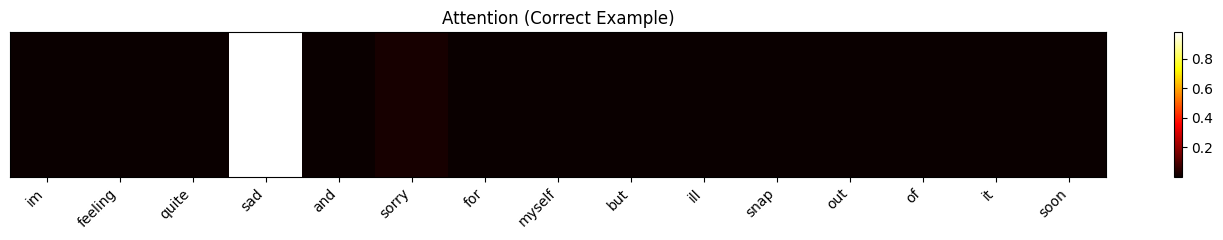


Wrong Example


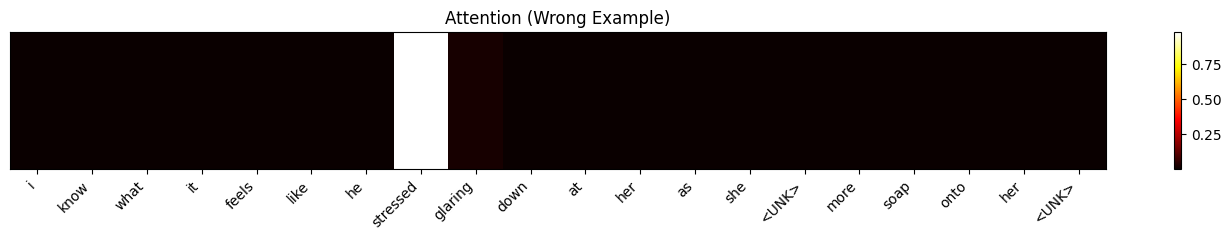

In [32]:
correct_example = get_example_from_loader(
    bilstm_attn_model, dev_loader, device, idx2word, want_correct=True
)

wrong_example = get_example_from_loader(
    bilstm_attn_model, dev_loader, device, idx2word, want_correct=False
)

print("\nCorrect Example")
plot_attention_heatmap(correct_example["words"], correct_example["attn"],
                       title="Attention (Correct Example)")

print("\nWrong Example")
plot_attention_heatmap(wrong_example["words"], wrong_example["attn"],
                       title="Attention (Wrong Example)")

In [45]:
print("\nTransformer")
transformer_model = TransformerEncoderClassifier(
        vocab_size=len(vocab),
        embedding_dim=100,
        num_heads=4,
        num_layers=2,
        hidden_dim=256,
        num_classes=6,
        max_len=max_len,
        dropout=0.1
    ).to(device)

optimizer = optim.Adam(transformer_model.parameters(), lr=0.0005)
transformer_model = train_model(transformer_model, train_loader, dev_loader, criterion, optimizer,
                                   num_epochs=20, model_name="Transformer")


Transformer

Training Transformer...


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:515: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch 1/20 | Train Loss: 1.5216 | Train Acc: 0.4439 | Train F1: 0.2464 | Dev Acc: 0.4365 | Dev F1: 0.2453 | Time: 5.55s
Epoch 2/20 | Train Loss: 1.0793 | Train Acc: 0.7268 | Train F1: 0.6871 | Dev Acc: 0.6360 | Dev F1: 0.6093 | Time: 5.51s
Epoch 3/20 | Train Loss: 0.6388 | Train Acc: 0.8445 | Train F1: 0.8237 | Dev Acc: 0.7565 | Dev F1: 0.7477 | Time: 5.16s
Epoch 4/20 | Train Loss: 0.4088 | Train Acc: 0.8944 | Train F1: 0.8766 | Dev Acc: 0.7865 | Dev F1: 0.7784 | Time: 9.92s
Epoch 5/20 | Train Loss: 0.2886 | Train Acc: 0.9141 | Train F1: 0.8986 | Dev Acc: 0.7935 | Dev F1: 0.7804 | Time: 6.51s
Epoch 6/20 | Train Loss: 0.1999 | Train Acc: 0.9451 | Train F1: 0.9283 | Dev Acc: 0.8135 | Dev F1: 0.7831 | Time: 5.32s
Epoch 7/20 | Train Loss: 0.1547 | Train Acc: 0.9585 | Train F1: 0.9465 | Dev Acc: 0.8180 | Dev F1: 0.7990 | Time: 7.35s
Epoch 8/20 | Train Loss: 0.1246 | Train Acc: 0.9655 | Train F1: 0.9534 | Dev Acc: 0.8255 | Dev F1: 0.8076 | Time: 5.18s
Epoch 9/20 | Train Loss: 0.1001 | Train 

In [46]:
print("\nTransformer - Development Set:")
transformer_dev_metrics = evaluate(transformer_model, dev_loader, criterion, device)
print_metrics(transformer_dev_metrics, "Transformer Dev")


Transformer - Development Set:

Transformer Dev Results:
Accuracy: 0.8490
Macro Precision: 0.8248
Macro Recall: 0.8259
Macro F1: 0.8250

Per-class metrics:
  sadness   : P=0.8556, R=0.8727, F1=0.8641
  joy       : P=0.8822, R=0.8722, F1=0.8771
  love      : P=0.7713, R=0.8146, F1=0.7923
  anger     : P=0.8784, R=0.8145, F1=0.8453
  fear      : P=0.7864, R=0.8160, F1=0.8009
  surprise  : P=0.7750, R=0.7654, F1=0.7702

Confusion Matrix:
[[480  31   7  13  16   3]
 [ 35 614  30   9  11   5]
 [  5  24 145   4   0   0]
 [ 25  14   2 224  10   0]
 [ 11   9   4   5 173  10]
 [  5   4   0   0  10  62]]


In [47]:
print("\nTransformer - Test Set:")
transformer_test_metrics = evaluate(transformer_model, test_loader, criterion, device)
print_metrics(transformer_test_metrics, "Transformer Test")


Transformer - Test Set:

Transformer Test Results:
Accuracy: 0.8280
Macro Precision: 0.7819
Macro Recall: 0.7896
Macro F1: 0.7846

Per-class metrics:
  sadness   : P=0.8982, R=0.8503, F1=0.8736
  joy       : P=0.8430, R=0.8576, F1=0.8502
  love      : P=0.6094, R=0.7358, F1=0.6667
  anger     : P=0.8619, R=0.8400, F1=0.8508
  fear      : P=0.7972, R=0.7723, F1=0.7846
  surprise  : P=0.6818, R=0.6818, F1=0.6818

Confusion Matrix:
[[494  42  11  17  13   4]
 [ 15 596  58  10   9   7]
 [  5  35 117   0   1   1]
 [ 15  17   2 231   9   1]
 [ 19  12   4   8 173   8]
 [  2   5   0   2  12  45]]


In [48]:
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)

models_results = [
    ("LSTM", lstm_test_metrics),
    ("BiLSTM", bilstm_test_metrics),
    ("BiRNN", birnn_test_metrics),
    ("BiLSTM+Attention", bilstm_attn_test_metrics),
    ("Transformer", transformer_test_metrics)
]

print(f"\n{'Model':<20} {'Test Acc':<12} {'Test Macro F1':<15}")
print("-" * 50)
for name, metrics in models_results:
    print(f"{name:<20} {metrics['accuracy']:<12.4f} {metrics['macro_f1']:<15.4f}")

print("\n" + "="*60)
print("TRAINING COMPLETE!")


FINAL SUMMARY

Model                Test Acc     Test Macro F1  
--------------------------------------------------
LSTM                 0.3475       0.0908         
BiLSTM               0.9165       0.8758         
BiRNN                0.4745       0.2568         
BiLSTM+Attention     0.9300       0.8833         
Transformer          0.8280       0.7846         

TRAINING COMPLETE!
